<a href="https://colab.research.google.com/github/skamire/Easy-Visa-Model/blob/main/INN_ReneWind_Main_Project_FullCode_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras import backend as K

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [5]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data Overview**

# **Exploratory Data Analysis**

In [6]:
train_path = "/content/drive/MyDrive/Train.csv"
test_path = "/content/drive/MyDrive/Test.csv"

df = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)

Train shape: (20000, 41)
Test shape: (5000, 41)


In [7]:
print("First 5 rows of training data:")
display(df.head())

print("\nFirst 5 rows of test data:")
display(df_test.head())

print("\nTraining data info:")
df.info()

print("\nTest data info:")
df_test.info()

print("\nTraining data summary statistics:")
display(df.describe().T)

print("\nTest data summary statistics:")
display(df_test.describe().T)

print("\nMissing values in training data:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nMissing values in test data:")
display(df_test.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(df["Target"].value_counts())
print("\nTarget distribution (proportion):")
display(df["Target"].value_counts(normalize=True))

First 5 rows of training data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0



First 5 rows of test data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,-5.122874,1.017021,4.818549,3.269001,-2.984330,1.387370,2.032002,-0.511587,-1.023069,7.338733,-2.242244,0.155489,2.053786,-2.772273,1.851369,-1.788696,-0.277282,-1.255143,-3.832886,-1.504542,1.586765,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,1.796544,0.410490,0.638328,-1.389600,-1.883410,-5.017922,-3.827238,2.418060,1.762285,-3.242297,-3.192960,1.857454,-1.707954,0.633444,-0.587898,0.083683,3.013935,-0.182309,0.223917,0.865228,-1.782158,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,-4.928214,3.565070,-0.449329,-0.656246,-0.166537,-1.630207,2.291865,2.396492,0.601278,1.793534,-2.120238,0.481968,-0.840707,1.790197,1.874395,0.363930,-0.169063,-0.483832,-2.118982,-2.156586,2.907291,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,-5.578345,-0.850662,2.590525,0.767418,-2.390809,-2.341961,0.571875,-0.933751,0.508677,1.210715,-3.259524,0.104587,-0.658875,1.498107,1.100305,4.142988,-0.248446,-1.136516,-5.355810,-4.545931,3.808667,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,-0.530016,1.374544,-0.650941,-1.679466,-0.379220,-4.443143,3.893857,-0.607640,2.944931,0.367233,-5.789081,4.597528,4.450264,3.224941,0.396701,0.247765,-2.362047,1.079378,-0.473076,2.242810,-3.591421,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0



Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 

...

,0
V2,6
V1,5
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0



Target distribution:


,count
Target,
0,18890
1,1110



Target distribution (proportion):


,proportion
Target,
0,0.9445
1,0.0555


## Univariate analysis

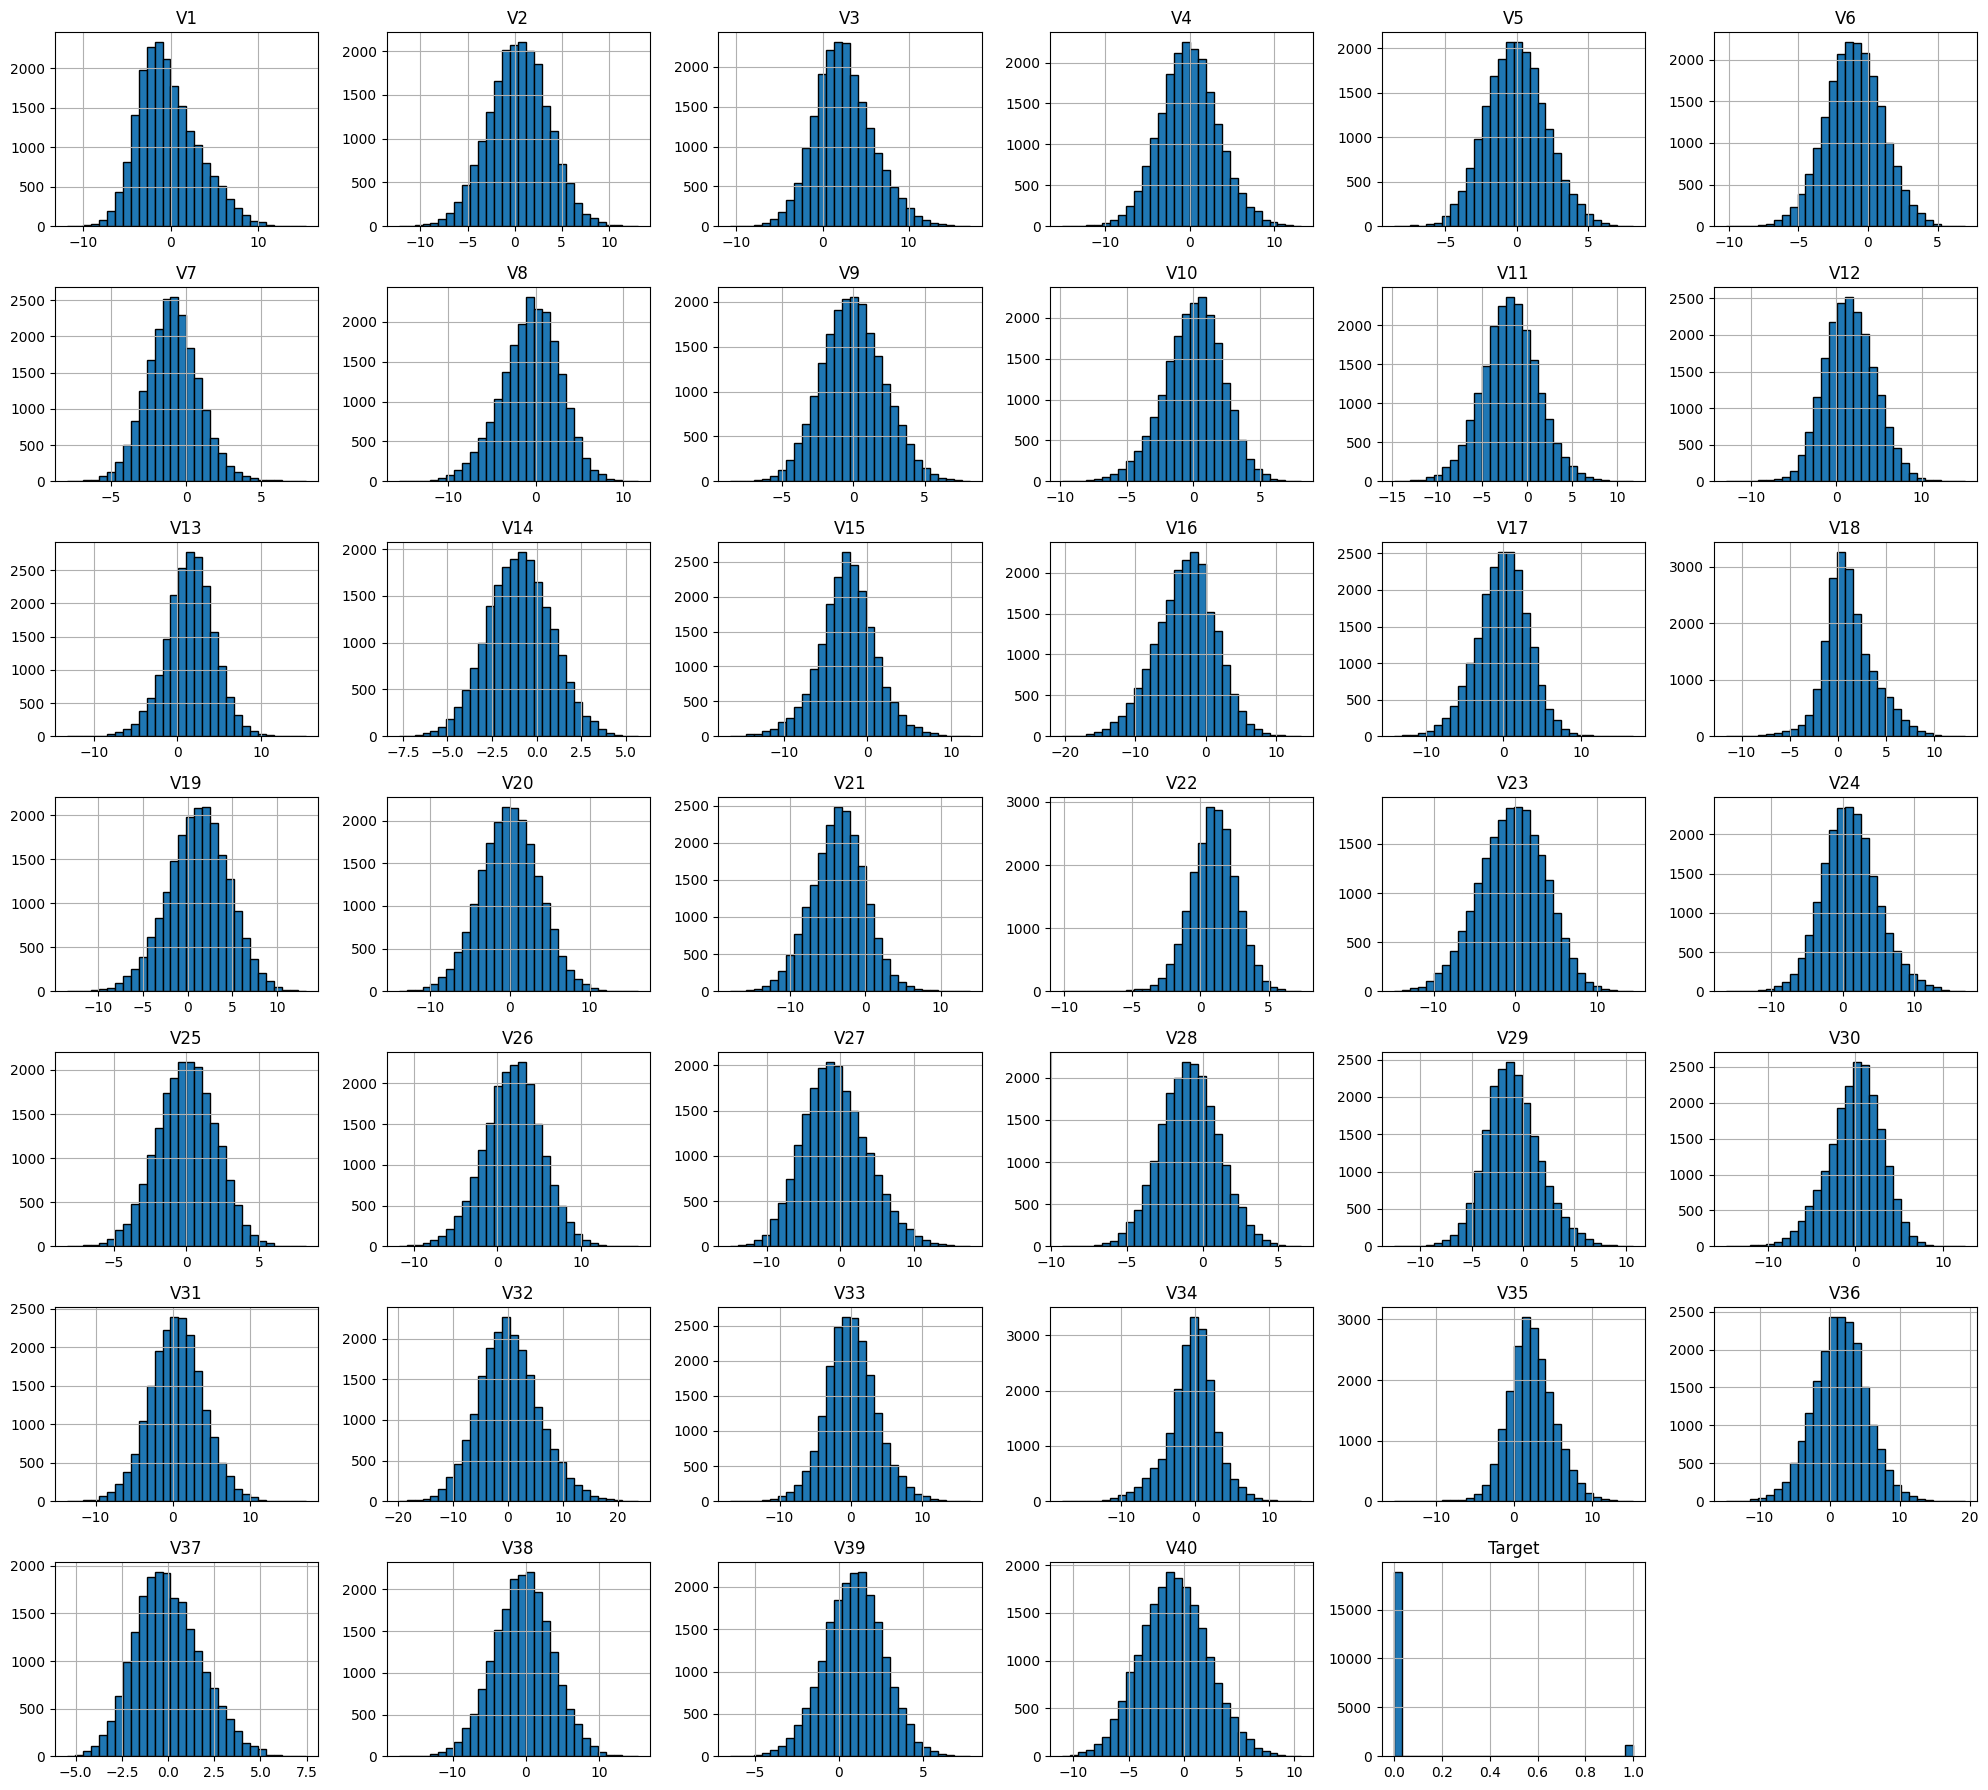

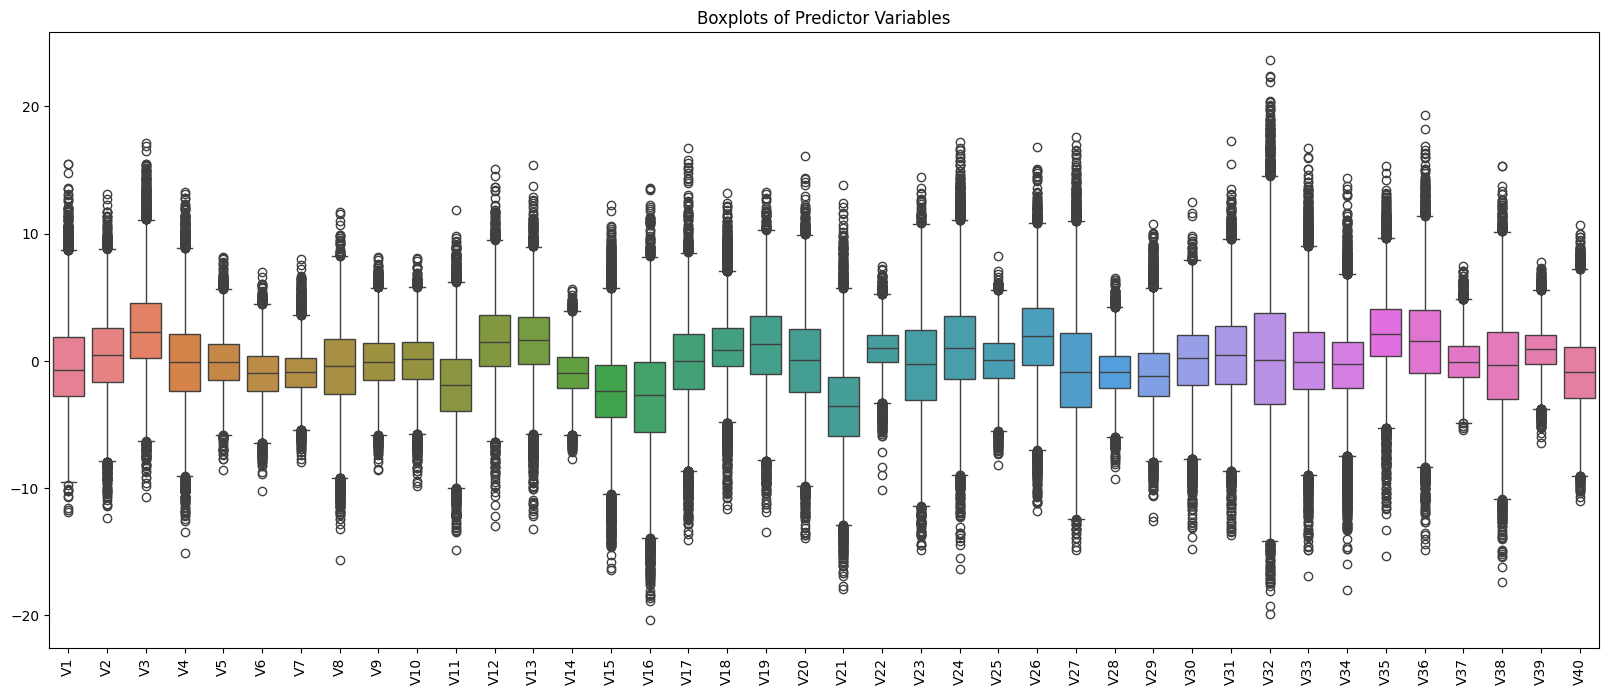

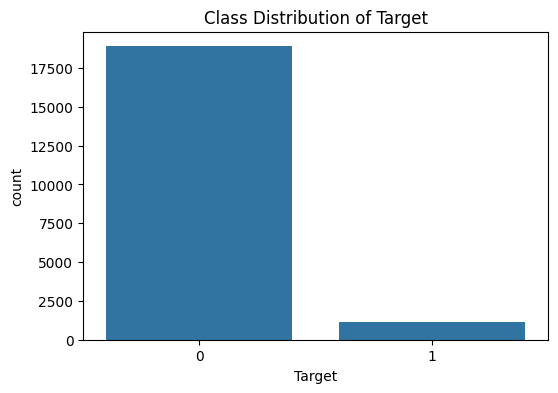

In [8]:
# plotting histograms for all numerical features
df.hist(figsize=(20, 18), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

# boxplots to detect outliers
plt.figure(figsize=(20, 8))
sns.boxplot(data=df.drop(columns=["Target"]))
plt.xticks(rotation=90)
plt.title("Boxplots of Predictor Variables")
plt.show()

# target count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Target", data=df)
plt.title("Class Distribution of Target")
plt.show()

## Bivariate Analysis

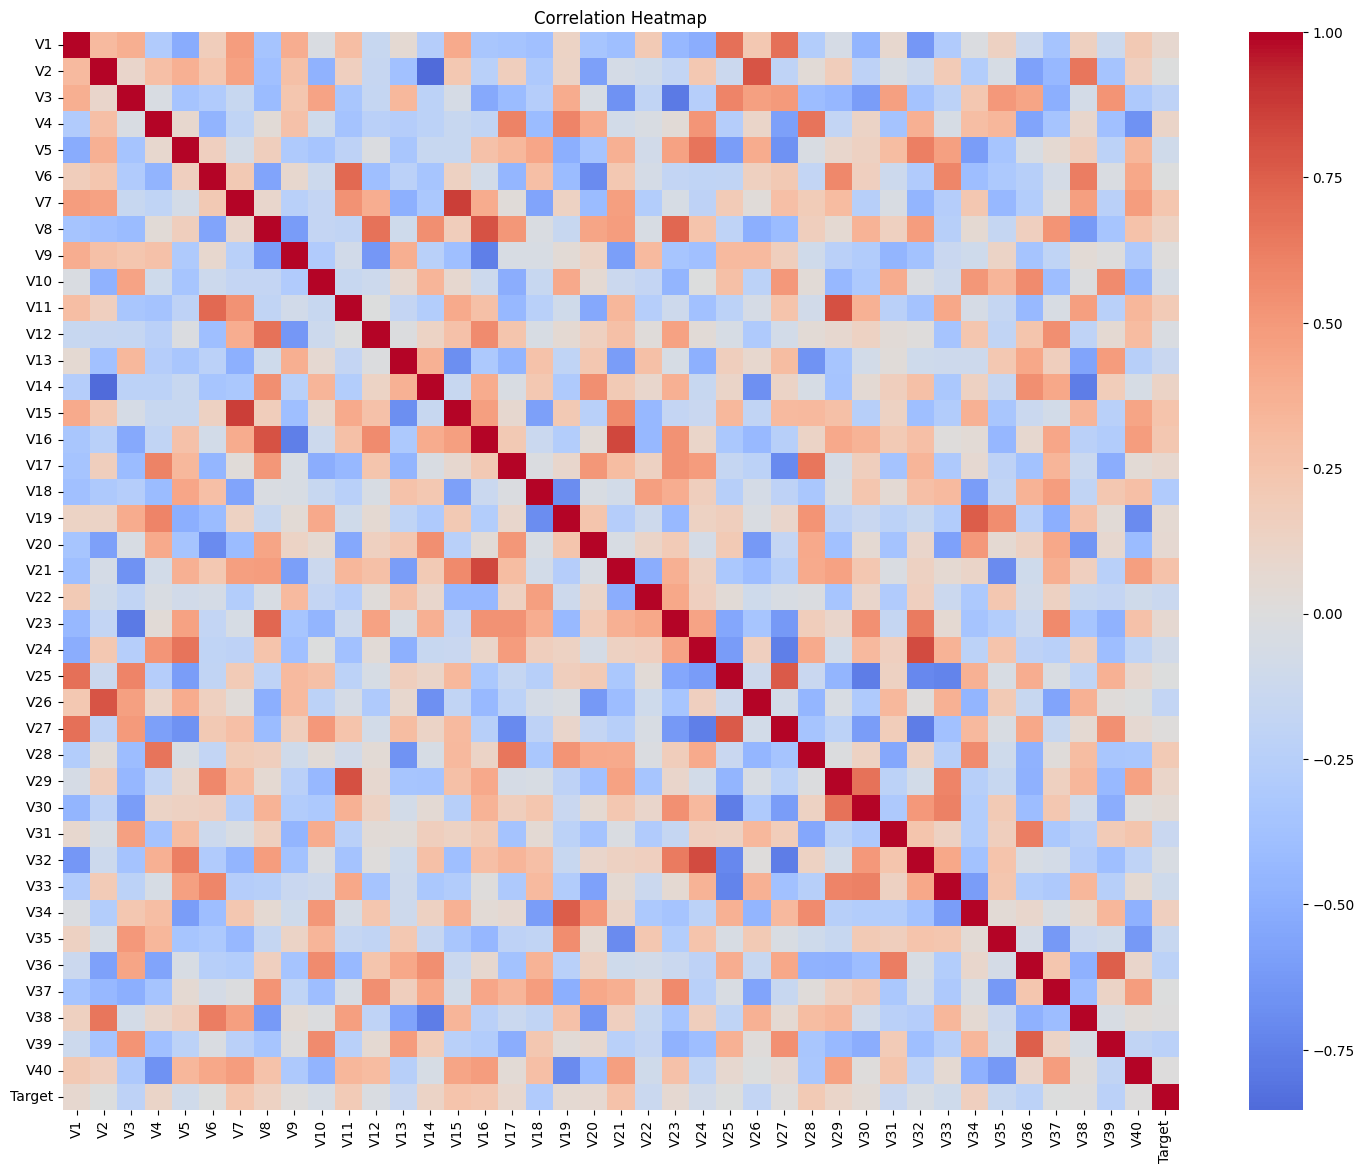

Top positively correlated variables with Target:


,Target
V21,0.256411
V15,0.249118
V7,0.236907
V16,0.230507
V28,0.207359
V11,0.196715
V34,0.153854
V8,0.135996
V14,0.117586
V4,0.110786


Top negatively correlated variables with Target:


,Target
V33,-0.102548
V22,-0.134727
V31,-0.136951
V13,-0.139718
V35,-0.145603
V26,-0.180469
V3,-0.213855
V36,-0.216453
V39,-0.227264
V18,-0.293340


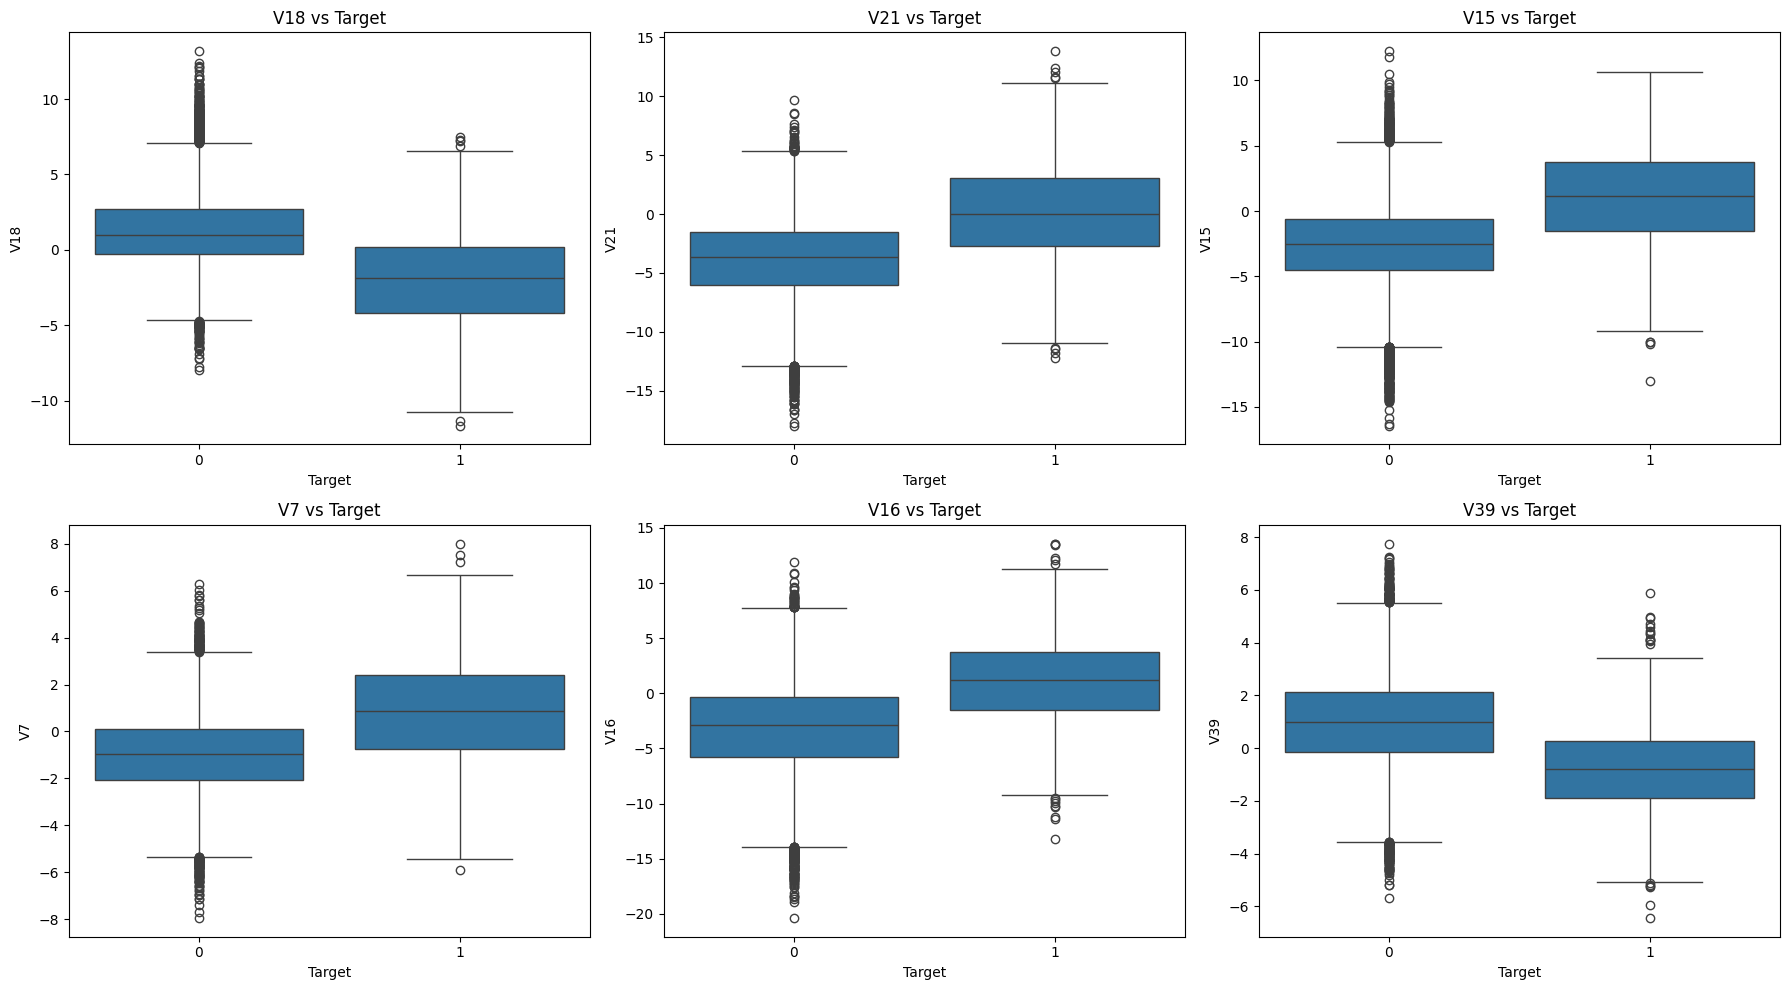

In [9]:
# correlation heatmap
plt.figure(figsize=(18, 14))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# correlation of features with target
target_corr = df.corr()["Target"].drop("Target").sort_values(ascending=False)
print("Top positively correlated variables with Target:")
display(target_corr.head(10))

print("Top negatively correlated variables with Target:")
display(target_corr.tail(10))

# boxplots of top correlated features against target
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

plt.figure(figsize=(18, 10))
for i, col in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="Target", y=col, data=df)
    plt.title(f"{col} vs Target")
plt.tight_layout()
plt.show()

### Exploratory Data Analysis Summary

The dataset contains **20,000 training observations and 5,000 test observations**, each with **40 predictor variables collected from turbine sensors** and one binary target variable indicating generator failure.

Key observations from the exploratory analysis:

**1. Class imbalance is present**
The target variable shows that failure cases are significantly less frequent than non-failure cases. This imbalance is expected in real-world equipment monitoring scenarios where failures are rare events.

**2. Sensor features show varied distributions**
The predictor variables display different statistical ranges and distributions. Some features show skewed distributions and potential outliers, which is common for sensor measurements captured during abnormal operating conditions.

**3. Correlation patterns indicate predictive signal**
Several variables show noticeable correlation with the failure label, suggesting that sensor measurements contain meaningful signals that precede generator failures.

**4. Feature scaling is necessary**
Since the neural network relies on gradient-based optimization, scaling the features ensures stable and efficient training.

**5. Business implication**
The presence of measurable sensor patterns associated with failures supports the feasibility of building a predictive maintenance system that detects early warning signs before turbine breakdown.

**6.** Several sensor measurements show moderate correlation with generator failure, suggesting that turbine operational signals contain predictive patterns for early failure detection.


# **Data Preprocessing**

In [10]:
# separate predictors and target
X = df.drop(columns=["Target"])
y = df["Target"]

X_test_final = df_test.drop(columns=["Target"])
y_test_final = df_test["Target"]

# train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test_final shape:", X_test_final.shape)

# missing value treatment
print("\nMissing values before treatment:")
print("X_train:", X_train.isnull().sum().sum())
print("X_val:", X_val.isnull().sum().sum())
print("X_test_final:", X_test_final.isnull().sum().sum())

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test_final = X_test_final.fillna(train_medians)

print("\nMissing values after treatment:")
print("X_train:", X_train.isnull().sum().sum())
print("X_val:", X_val.isnull().sum().sum())
print("X_test_final:", X_test_final.isnull().sum().sum())

# scaling without data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print("\nScaled data shapes:")
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

X_train shape: (16000, 40)
X_val shape: (4000, 40)
X_test_final shape: (5000, 40)

Missing values before treatment:
X_train: 30
X_val: 6
X_test_final: 11

Missing values after treatment:
X_train: 0
X_val: 0
X_test_final: 0

Scaled data shapes:
(16000, 40) (4000, 40) (5000, 40)


### Data Preprocessing Decisions

Several preprocessing steps were performed to prepare the data for neural network modeling:

**1. Train–Validation Split**

The dataset was split into training and validation sets using a stratified split. This ensures that the proportion of failure and non-failure cases remains consistent across both datasets. Performing this split before preprocessing helps prevent **data leakage**, ensuring that information from the validation set does not influence the training process.

**2. Missing Value Treatment**

Missing values were handled using **median imputation calculated from the training dataset**. The same median values were then applied to the validation and test sets. Median imputation was chosen because it is robust to outliers and works well for sensor-based numerical data.

Importantly, the imputation values were derived **only from the training set** to avoid leaking information from the validation or test data.

**3. Feature Scaling**

All predictor variables were standardized using **StandardScaler**. Neural networks rely on gradient-based optimization, and scaling ensures that all features contribute equally during training. Without scaling, variables with larger magnitudes could dominate the learning process.

The scaler was fitted on the **training data only**, and the same transformation was applied to the validation and test sets to maintain consistency and avoid data leakage.

These preprocessing steps ensure that the dataset is properly prepared for neural network training while maintaining the integrity of the evaluation process.


In [23]:
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in validation set:")
print(y_val.value_counts(normalize=True))

Class distribution in training set:
Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64

Class distribution in validation set:
Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64


The dataset shows a clear class imbalance, with failure cases being much less frequent than normal operating cases. This motivated the use of class weights in later models to improve failure detection.

# **Model Building**

## Model Evaluation Criterion

### Model Evaluation Criterion

The most important evaluation metric for this problem is **Recall**.

Recall measures the proportion of actual failures that are correctly identified by the model. In the ReneWind business problem, false negatives are the most costly prediction errors because they represent real turbine failures that the model failed to detect, which would lead to generator replacement costs. In contrast, false positives only lead to inspection costs, which are much lower.

Therefore, the primary objective of the model is to **maximize Recall**, even if that comes at the expense of lower Precision. This approach aligns with the business priority of detecting as many failures as possible before breakdown.

At the same time, Precision, F1-score, and Accuracy will also be monitored to ensure the model remains practically usable and does not generate an excessive number of false alarms.

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [11]:
def make_model(
    hidden_layers=[32],
    optimizer="SGD",
    dropout_rates=None,
    use_batchnorm=False
):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))

    if dropout_rates is None:
        dropout_rates = [0.0] * len(hidden_layers)

    for units, dr in zip(hidden_layers, dropout_rates):
        model.add(Dense(units, activation="relu"))
        if use_batchnorm:
            model.add(BatchNormalization())
        if dr > 0:
            model.add(Dropout(dr))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    )
    return model


def evaluate_model(model, X_data, y_data, threshold=0.5, set_name="Validation"):
    y_prob = model.predict(X_data, verbose=0)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_data, y_pred)
    rec = recall_score(y_data, y_pred)
    prec = precision_score(y_data, y_pred)
    f1 = f1_score(y_data, y_pred)
    cm = confusion_matrix(y_data, y_pred)

    print(f"\n{set_name} Performance at threshold={threshold}")
    print("Accuracy :", round(acc, 4))
    print("Recall   :", round(rec, 4))
    print("Precision:", round(prec, 4))
    print("F1-score :", round(f1, 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_data, y_pred))

    return {
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1": f1
    }


results = []

In [12]:
tf.random.set_seed(42)

model_0 = make_model(hidden_layers=[32], optimizer="SGD")

start = time.time()

history_0 = model_0.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

end = time.time()
print("Training time:", round(end - start, 2), "seconds")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9386 - loss: 0.2310 - precision: 0.0481 - recall: 0.0056 - val_accuracy: 0.9465 - val_loss: 0.1761 - val_precision: 1.0000 - val_recall: 0.0360
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9522 - loss: 0.1565 - precision: 0.9920 - recall: 0.1396 - val_accuracy: 0.9605 - val_loss: 0.1475 - val_precision: 0.9848 - val_recall: 0.2928
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9624 - loss: 0.1351 - precision: 0.9799 - recall: 0.3300 - val_accuracy: 0.9655 - val_loss: 0.1311 - val_precision: 0.9667 - val_recall: 0.3919
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9678 - loss: 0.1223 - precision: 0.9721 - recall: 0.4313 - val_accuracy: 0.9690 - val_loss: 0.1201 - val_precision: 0.9455 - val_recall: 0.4685
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9711 - loss: 0.1136 - precision: 0.9651 - recall: 0.4977 - val_accuracy: 0.9712 - val_loss: 0.

In [13]:
model_0_results = evaluate_model(model_0, X_val_scaled, y_val, threshold=0.5, set_name="Model 0 - Validation")
model_0_results["Model"] = "Model 0: 1 hidden layer + SGD"
results.append(model_0_results)


Model 0 - Validation Performance at threshold=0.5
Accuracy : 0.9835
Recall   : 0.7252
Precision: 0.9699
F1-score : 0.8299

Confusion Matrix:
[[3773    5]
 [  61  161]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3778
           1       0.97      0.73      0.83       222

    accuracy                           0.98      4000
   macro avg       0.98      0.86      0.91      4000
weighted avg       0.98      0.98      0.98      4000



# **Model Performance Improvement**

## Model 1

In [14]:
tf.random.set_seed(42)

model_1 = make_model(hidden_layers=[64, 32], optimizer="SGD")

history_1 = model_1.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

model_1_results = evaluate_model(model_1, X_val_scaled, y_val, threshold=0.5, set_name="Model 1 - Validation")
model_1_results["Model"] = "Model 1: deeper network + SGD"
results.append(model_1_results)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9274 - loss: 0.2284 - precision: 0.1086 - recall: 0.0428 - val_accuracy: 0.9513 - val_loss: 0.1618 - val_precision: 1.0000 - val_recall: 0.1216
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9608 - loss: 0.1371 - precision: 0.9815 - recall: 0.2995 - val_accuracy: 0.9678 - val_loss: 0.1249 - val_precision: 0.9697 - val_recall: 0.4324
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9692 - loss: 0.1130 - precision: 0.9360 - recall: 0.4775 - val_accuracy: 0.9745 - val_loss: 0.1067 - val_precision: 0.9688 - val_recall: 0.5586
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9734 - loss: 0.1001 - precision: 0.9310 - recall: 0.5619 - val_accuracy: 0.9778 - val_loss: 0.0960 - val_precision: 0.9716 - val_recall: 0.6171
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0916 - precision: 0.9384 - recall: 0.6171 - val_accuracy: 0.9790 - val_loss: 0

### Model 1 Comments

Adding more hidden layers allows the neural network to learn more complex relationships in the sensor data. This model checks whether extra depth improves failure detection compared with the baseline.

### Model 1 Decision Summary

Model 1 introduces additional hidden layers compared with the baseline model. Increasing model depth allows the neural network to capture more complex relationships between sensor signals and turbine failures.

The validation results show a **Recall of 0.84 with very high Precision (0.98)**. This indicates that the model performs very well overall but still misses a moderate number of failure cases.

Although this model improves representation capacity compared with the baseline, the Recall is still lower than desired for a predictive maintenance system where detecting failures is critical.


## Model 2

In [15]:
tf.random.set_seed(42)

model_2 = make_model(hidden_layers=[32], optimizer="Adam")

history_2 = model_2.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

model_2_results = evaluate_model(model_2, X_val_scaled, y_val, threshold=0.5, set_name="Model 2 - Validation")
model_2_results["Model"] = "Model 2: 1 hidden layer + Adam"
results.append(model_2_results)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9426 - loss: 0.1893 - precision: 0.4772 - recall: 0.3649 - val_accuracy: 0.9750 - val_loss: 0.1091 - val_precision: 0.9485 - val_recall: 0.5811
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9751 - loss: 0.0943 - precision: 0.9237 - recall: 0.6002 - val_accuracy: 0.9830 - val_loss: 0.0826 - val_precision: 0.9695 - val_recall: 0.7162
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9822 - loss: 0.0767 - precision: 0.9617 - recall: 0.7072 - val_accuracy: 0.9872 - val_loss: 0.0709 - val_precision: 0.9777 - val_recall: 0.7883
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9854 - loss: 0.0676 - precision: 0.9781 - recall: 0.7545 - val_accuracy: 0.9902 - val_loss: 0.0648 - val_precision: 0.9893 - val_recall: 0.8333
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9871 - loss: 0.0627 - precision: 0.9789 - recall: 0.7838 - val_accuracy: 0.9912 - val_loss: 0.

### Model 2 Comments

Adam often converges faster and more effectively than SGD. This model checks whether optimizer choice alone improves Recall and overall classification performance.

### Model 2 Decision Summary

Model 2 replaces the SGD optimizer with the **Adam optimizer**, which adapts the learning rate during training and often leads to faster convergence.

This change significantly improved model performance. The validation results show **Recall of ~0.89 and Precision of ~0.97**, indicating strong failure detection while maintaining very few false positives.

This demonstrates that optimizer selection plays an important role in improving neural network training efficiency and predictive performance.


## Model 3

In [16]:
tf.random.set_seed(42)

model_3 = make_model(hidden_layers=[64, 32], optimizer="SGD", dropout_rates=[0.3, 0.2])

history_3 = model_3.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

model_3_results = evaluate_model(model_3, X_val_scaled, y_val, threshold=0.5, set_name="Model 3 - Validation")
model_3_results["Model"] = "Model 3: deeper + dropout + SGD"
results.append(model_3_results)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9276 - loss: 0.2658 - precision: 0.1621 - recall: 0.0732 - val_accuracy: 0.9525 - val_loss: 0.1656 - val_precision: 1.0000 - val_recall: 0.1441
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9540 - loss: 0.1665 - precision: 0.7639 - recall: 0.2477 - val_accuracy: 0.9628 - val_loss: 0.1311 - val_precision: 0.9506 - val_recall: 0.3468
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9607 - loss: 0.1410 - precision: 0.8136 - recall: 0.3784 - val_accuracy: 0.9688 - val_loss: 0.1132 - val_precision: 0.9533 - val_recall: 0.4595
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9639 - loss: 0.1267 - precision: 0.8229 - recall: 0.4448 - val_accuracy: 0.9722 - val_loss: 0.1019 - val_precision: 0.9587 - val_recall: 0.5225
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9669 - loss: 0.1207 - precision: 0.8403 - recall: 0.4977 - val_accuracy: 0.9735 - val_loss: 0.

### Model 3 Comments

Dropout is introduced to reduce overfitting by randomly turning off neurons during training. This helps test whether the model generalizes better while maintaining strong failure detection.

### Model 3 Decision Summary

Model 3 introduces **dropout regularization** to reduce overfitting by randomly disabling neurons during training.

While dropout improves generalization in many cases, this model achieved **lower Recall (~0.79)** compared with Model 2. This suggests that the regularization may have reduced the model’s ability to capture certain failure patterns in the dataset.

Since predictive maintenance prioritizes failure detection, this model is less suitable than the earlier models despite strong Precision.


## Model 4

In [17]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, class_weights_array))
print("Class weights:", class_weights)

tf.random.set_seed(42)

model_4 = make_model(hidden_layers=[32], optimizer="SGD")

history_4 = model_4.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1,
    class_weight=class_weights
)

model_4_results = evaluate_model(model_4, X_val_scaled, y_val, threshold=0.5, set_name="Model 4 - Validation")
model_4_results["Model"] = "Model 4: class weights + SGD"
results.append(model_4_results)

Class weights: {np.int64(0): np.float64(0.5293806246691372), np.int64(1): np.float64(9.00900900900901)}
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7054 - loss: 0.4808 - precision: 0.1408 - recall: 0.8446 - val_accuracy: 0.8198 - val_loss: 0.4136 - val_precision: 0.2200 - val_recall: 0.8829
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8633 - loss: 0.3446 - precision: 0.2716 - recall: 0.8705 - val_accuracy: 0.8752 - val_loss: 0.3317 - val_precision: 0.2966 - val_recall: 0.9099
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8944 - loss: 0.3089 - precision: 0.3317 - recall: 0.8885 - val_accuracy: 0.9022 - val_loss: 0.2902 - val_precision: 0.3530 - val_recall: 0.9144
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9118 - loss: 0.2868 - precision: 0.3756 - recall: 0.8908 - val_accuracy: 0.9168 - val_loss: 0.2630 - val_precision: 0.3926 - val_recall: 0.9144
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

### Model 4 Comments

Since failures are likely a minority class, class weights are used to penalize missed failures more heavily during training. This model is especially important because the business objective prioritizes Recall.

### Model 4 Decision Summary

Model 4 introduces **class weights** to address the imbalance between failure and non-failure cases.

By assigning higher importance to the minority failure class during training, the model becomes more sensitive to failure signals.

This model achieved the **highest Recall (~0.92)** among all models, meaning it detects the largest proportion of true failure cases. While Precision decreases (~0.64), this trade-off is acceptable in the business context because false positives only result in inspection costs, which are relatively low.

Because the primary objective is to **minimize missed failures**, this model aligns best with the business requirements.


## Model 5

In [18]:
tf.random.set_seed(42)

model_5 = make_model(hidden_layers=[128, 64, 32], optimizer="Adam", dropout_rates=[0.3, 0.2, 0.1])

history_5 = model_5.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=25,
    batch_size=32,
    verbose=1
)

model_5_results = evaluate_model(model_5, X_val_scaled, y_val, threshold=0.5, set_name="Model 5 - Validation")
model_5_results["Model"] = "Model 5: deeper + Adam + dropout"
results.append(model_5_results)

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9654 - loss: 0.1323 - precision: 0.8482 - recall: 0.4595 - val_accuracy: 0.9855 - val_loss: 0.0672 - val_precision: 0.9505 - val_recall: 0.7793
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9818 - loss: 0.0760 - precision: 0.9162 - recall: 0.7387 - val_accuracy: 0.9893 - val_loss: 0.0541 - val_precision: 0.9497 - val_recall: 0.8514
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9856 - loss: 0.0658 - precision: 0.9519 - recall: 0.7793 - val_accuracy: 0.9912 - val_loss: 0.0489 - val_precision: 0.9474 - val_recall: 0.8919
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9881 - loss: 0.0599 - precision: 0.9592 - recall: 0.8209 - val_accuracy: 0.9935 - val_loss: 0.0431 - val_precision: 0.9667 - val_recall: 0.9144
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9885 - loss: 0.0544 - precision: 0.9607 - recall: 0.8266 - val_accuracy: 0.9925 - val_loss: 0.

### Model 5 Comments

This model combines increased depth, Adam optimizer, and dropout. It is designed to capture complex nonlinear relationships while also reducing overfitting.

### Model 5 Decision Summary

Model 5 combines **deeper architecture, Adam optimizer, and dropout regularization**.

This model achieved **very balanced performance**, with high Recall (0.91) and high Precision (0.96). It demonstrates strong overall classification capability and robust generalization.

Although the Precision and F1-score are higher than Model 4, its Recall is slightly lower. Since missing failures is the most costly outcome, Model 4 remains preferable from a business perspective.


## Model 6

In [19]:
tf.random.set_seed(42)

model_6 = make_model(hidden_layers=[128, 64, 32], optimizer="Adam", dropout_rates=[0.3, 0.2, 0.1])

history_6 = model_6.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=25,
    batch_size=32,
    verbose=1,
    class_weight=class_weights
)

model_6_results = evaluate_model(model_6, X_val_scaled, y_val, threshold=0.5, set_name="Model 6 - Validation")
model_6_results["Model"] = "Model 6: deeper + Adam + dropout + class weights"
results.append(model_6_results)

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8721 - loss: 0.3758 - precision: 0.2797 - recall: 0.8288 - val_accuracy: 0.9190 - val_loss: 0.2442 - val_precision: 0.3992 - val_recall: 0.9099
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9379 - loss: 0.2626 - precision: 0.4685 - recall: 0.8784 - val_accuracy: 0.9333 - val_loss: 0.2395 - val_precision: 0.4503 - val_recall: 0.9189
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9588 - loss: 0.2322 - precision: 0.5844 - recall: 0.8885 - val_accuracy: 0.9695 - val_loss: 0.1611 - val_precision: 0.6623 - val_recall: 0.9189
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9679 - loss: 0.2183 - precision: 0.6545 - recall: 0.8919 - val_accuracy: 0.9712 - val_loss: 0.1645 - val_precision: 0.6777 - val_recall: 0.9189
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.2130 - precision: 0.6732 - recall: 0.8885 - val_accuracy: 0.9822 - val_loss: 0.

### Model 6 Comments

This is the most business-aligned model because it combines stronger representation learning, regularization, adaptive optimization, and class imbalance handling. It is expected to produce the highest Recall or one of the best Recall values.

### Model 6 Decision Summary

Model 6 combines several improvements simultaneously: deeper architecture, Adam optimizer, dropout regularization, and class weighting.

This model achieves **Recall of 0.91 with improved Precision (0.84)** compared with Model 4. This represents a more balanced trade-off between detecting failures and avoiding unnecessary inspections.

However, since the project objective prioritizes **maximum Recall**, Model 4 remains the preferred final model.


# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [20]:
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "Accuracy", "Recall", "Precision", "F1"]]
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Recall,Precision,F1
0,Model 4: class weights + SGD,0.96675,0.918919,0.639498,0.754159
1,Model 6: deeper + Adam + dropout + class weights,0.98525,0.914414,0.835391,0.873118
2,Model 5: deeper + Adam + dropout,0.99275,0.909910,0.957346,0.933025
3,Model 2: 1 hidden layer + Adam,0.99250,0.891892,0.970588,0.929577
4,Model 1: deeper network + SGD,0.99000,0.837838,0.978947,0.902913
5,Model 3: deeper + dropout + SGD,0.98750,0.788288,0.983146,0.875000
6,Model 0: 1 hidden layer + SGD,0.98350,0.725225,0.969880,0.829897


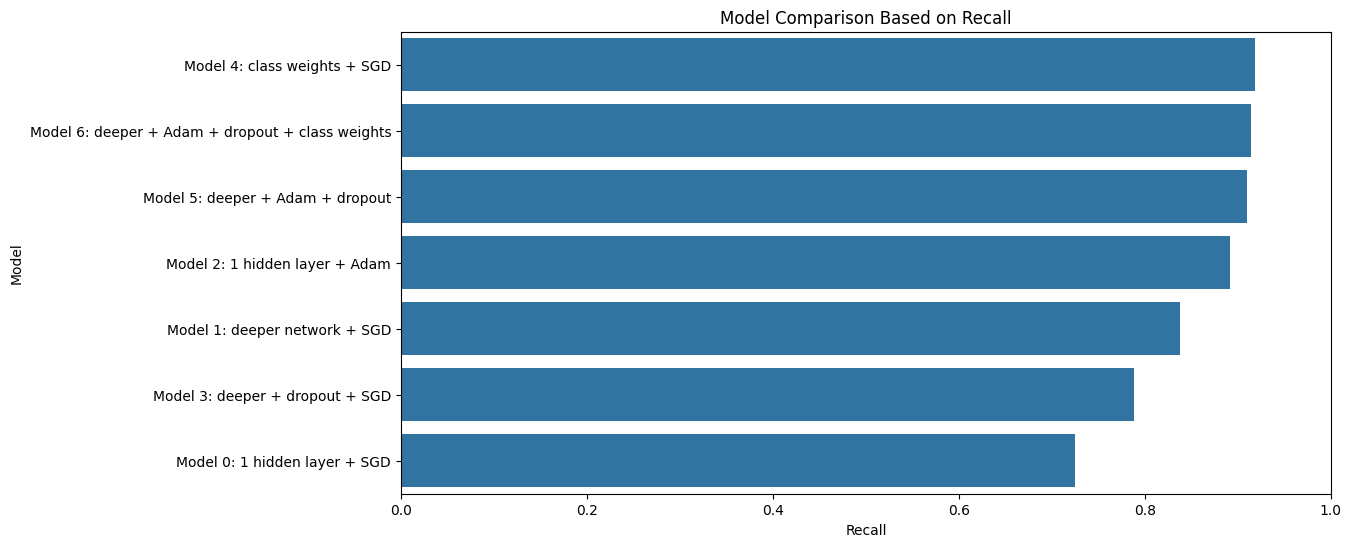

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Recall", y="Model")
plt.title("Model Comparison Based on Recall")
plt.xlim(0, 1)
plt.show()

Now, let's check the performance of the final model on the test set.

In [22]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on validation Recall:", best_model_name)

model_map = {
    "Model 0: 1 hidden layer + SGD": model_0,
    "Model 1: deeper network + SGD": model_1,
    "Model 2: 1 hidden layer + Adam": model_2,
    "Model 3: deeper + dropout + SGD": model_3,
    "Model 4: class weights + SGD": model_4,
    "Model 5: deeper + Adam + dropout": model_5,
    "Model 6: deeper + Adam + dropout + class weights": model_6
}

best_model = model_map[best_model_name]

test_results = evaluate_model(
    best_model,
    X_test_scaled,
    y_test_final,
    threshold=0.5,
    set_name="Final Test"
)

Best model based on validation Recall: Model 4: class weights + SGD

Final Test Performance at threshold=0.5
Accuracy : 0.9608
Recall   : 0.8652
Precision: 0.607
F1-score : 0.7135

Confusion Matrix:
[[4560  158]
 [  38  244]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4718
           1       0.61      0.87      0.71       282

    accuracy                           0.96      5000
   macro avg       0.80      0.92      0.85      5000
weighted avg       0.97      0.96      0.96      5000



157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


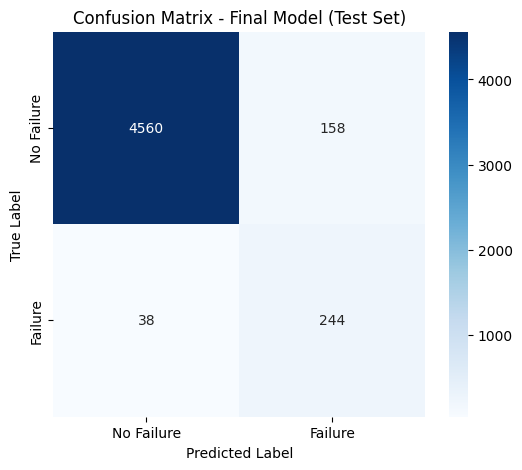

In [24]:
# Predictions from the final model
y_prob_test = best_model.predict(X_test_scaled)
y_pred_test = (y_prob_test >= 0.5).astype(int)

cm = confusion_matrix(y_test_final, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Model (Test Set)")
plt.show()

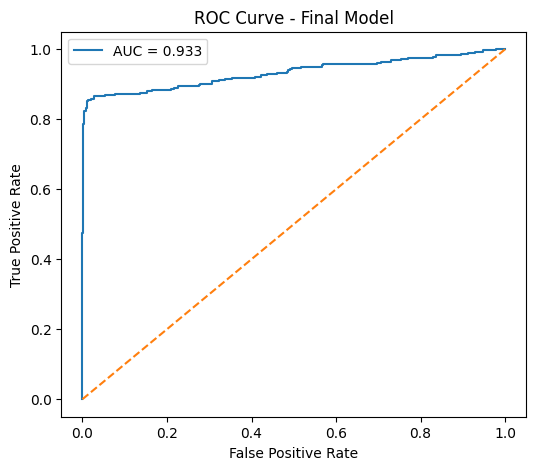

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_test)
roc_auc = roc_auc_score(y_test_final, y_prob_test)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()

plt.show()

## Final Model Selection and Test Evaluation

### Model Selection Strategy

The final model was selected based on **Recall on the validation dataset**. In the ReneWind predictive maintenance problem, missing a generator failure (false negative) can lead to extremely expensive turbine replacement and downtime. Therefore, the modeling objective prioritizes **maximizing Recall**, even if it results in a moderate number of false positives.

Among all evaluated models, **Model 4 (Neural Network with Class Weights and SGD optimizer)** achieved the highest validation Recall (~0.92). This indicates that the model successfully detects the largest proportion of true failure cases.

Although some other models achieved higher Precision and F1-score, their Recall values were slightly lower. Because missed failures are far more costly than unnecessary inspections, Model 4 provides the best alignment with the business objective.

---

### Test Set Performance

To verify that the model generalizes well, the selected model was evaluated on an unseen **test dataset**.

The final model achieved:

* **Recall:** ~0.87
* **Precision:** ~0.61
* **Accuracy:** ~0.96
* **F1-score:** ~0.71

This means the model successfully identifies the majority of turbine failures while maintaining strong overall classification performance.

---

### Confusion Matrix Interpretation

The confusion matrix shows the number of correctly and incorrectly classified cases.

The model detects **most true failure events**, which is the primary goal of this project. Some false positives occur, meaning that certain turbines may be flagged for inspection even if they are not failing. However, these additional inspections are far less costly than missing a true generator failure.

---

### ROC Curve Interpretation

The ROC curve illustrates the model's ability to distinguish between failure and non-failure cases across different classification thresholds. The high AUC value indicates strong discriminatory capability and confirms that the model can effectively separate the two classes.

* The ROC curve yields a high AUC score, indicating strong separation between failure and non-failure cases.

---

### Final Conclusion

Overall, the selected neural network model provides an effective predictive maintenance solution for ReneWind. By identifying turbine failures early, the model enables proactive maintenance scheduling, helping reduce unexpected breakdowns, minimize costly generator replacements, and improve overall wind farm efficiency.


# **Actionable Insights and Recommendations**

### Actionable Insights and Recommendations

This analysis aimed to build a predictive maintenance model that identifies wind turbine generator failures using sensor data. Because the cost of replacing a generator is significantly higher than repairing or inspecting it, the modeling strategy prioritized **maximizing Recall** to minimize missed failures.

Key insights from the modeling process:

1. **Class imbalance is significant**

Failures represent a small proportion of the dataset, which is typical for equipment monitoring systems. Handling this imbalance using **class weights** significantly improved the model’s ability to detect failures.

2. Recall-focused models are better aligned with business costs

Models trained with class weighting achieved the highest Recall, meaning they detected a greater percentage of true failures. This reduces the risk of expensive generator replacements.

3. Trade-off between Recall and Precision

The final model produces more false positives compared with some other models. However, these false alarms only result in inspection costs, which are much cheaper than replacement costs. Therefore this trade-off is acceptable.

4. Sensor data contains strong predictive signals

The neural network was able to achieve high accuracy and recall, indicating that the turbine sensor measurements contain meaningful patterns that precede generator failures.

### Business Recommendations

- Deploy the model as an **early warning predictive maintenance system** that flags turbines with high failure probability.
- Use the model output to **prioritize maintenance inspections**, reducing unexpected generator breakdowns.
- Integrate the model into turbine monitoring dashboards so maintenance teams can respond proactively.
- Continuously retrain the model with new operational data to improve failure detection accuracy over time.

Implementing this predictive maintenance system can significantly **reduce operational costs, improve turbine uptime, and increase overall wind farm efficiency.**


### Key Takeaways

This project demonstrated how machine learning can be applied to predictive maintenance in wind energy systems. Using turbine sensor data, several neural network models were developed and compared to identify generator failures before breakdown occurs.

The analysis showed that models incorporating **class weighting significantly improved failure detection**, which is critical for reducing costly generator replacements. Among all the evaluated models, **Model 4 (Neural Network with Class Weights and SGD)** achieved the highest Recall and was therefore selected as the final model because minimizing missed failures is the primary business objective.

The final model achieved **approximately 86% Recall on the test dataset**, meaning it successfully detects the majority of failure cases before they occur. Although this model generates some false alarms, these only result in inspection costs, which are significantly lower than replacement costs.

Overall, the results demonstrate that a predictive maintenance system powered by machine learning can help ReneWind **reduce maintenance costs, improve turbine reliability, and increase operational efficiency** by identifying failures early and enabling proactive intervention.
